# Weekly Quantity Prediction - Z-Score Pipeline

This notebook keeps one modeling workflow (XGBoost) with z-score filtering, evaluation, explainability, ANOVA, and 2026 forecasting.


## Step 1 - Load and Clean

We load `cleaned_data.csv`, drop unused columns, verify shape/nulls, preview data, and save `produits_model.csv`.


In [2]:
# Imports and paths
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "cleaned_data.csv"
ARTIFACT_ROOT = Path.cwd().resolve() / "artifacts"
PROCESSED_DIR = ARTIFACT_ROOT / "processed"
FIG_DIR = ARTIFACT_ROOT / "figures"
MODEL_DIR = ARTIFACT_ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('RAW_PATH:', RAW_PATH)

import seaborn as sns
from scipy.stats import f_oneway
from sklearn.metrics import mean_absolute_percentage_error


RAW_PATH: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\data\raw\cleaned_data.csv


In [3]:
# Load data
# Use cp1252 first to match prior project files; fallback to utf-8.
try:
    df = pd.read_csv(RAW_PATH, encoding='cp1252')
except Exception:
    df = pd.read_csv(RAW_PATH, encoding='utf-8')

print('Shape before cleaning:', df.shape)
display(df.head(3))


Shape before cleaning: (507032, 17)


,reference,date,code,article,client,quantite,prix_de_vente,montant,pmp_stock,taux_mb,cbm,code_client,year,month,day,month_name,day_name
0,A0059,2024-01-01,2200,SOMAM YAGO PM,AAAAAA,2.0,420.0,840.0,0.0,NaN,0.02,AA000002,2024,1,1,January,Monday
1,A0059,2024-01-01,2185,SOMAM YAGO 1 L,AAAAAA,1.0,800.0,800.0,0.0,NaN,0.01,AA000002,2024,1,1,January,Monday
2,A0058,2024-01-01,70,PAPIER DE TABLE ROULEAU,AAAAAA,1.0,750.0,750.0,400.0,87.5,0.01,AA000002,2024,1,1,January,Monday


In [4]:
# Drop unused columns from checklist
cols_to_drop = [
    'reference', 'code', 'client', 'code_client',
    'montant', 'pmp_stock', 'taux_mb', 'cbm',
    'day', 'month_name', 'day_name'
]

existing_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=existing_drop)

print('Dropped columns:', existing_drop)
print('Shape after cleaning:', df.shape)
print('Null counts (non-zero only):')
nulls = df.isna().sum()
display(nulls[nulls > 0].sort_values(ascending=False))
display(df.head(3))


Dropped columns: ['reference', 'code', 'client', 'code_client', 'montant', 'pmp_stock', 'taux_mb', 'cbm', 'day', 'month_name', 'day_name']
Shape after cleaning: (507032, 6)
Null counts (non-zero only):


Series([], dtype: int64)

,date,article,quantite,prix_de_vente,year,month
0,2024-01-01,SOMAM YAGO PM,2.0,420.0,2024,1
1,2024-01-01,SOMAM YAGO 1 L,1.0,800.0,2024,1
2,2024-01-01,PAPIER DE TABLE ROULEAU,1.0,750.0,2024,1


In [5]:
# Save cleaned modeling file
produits_model_path = PROCESSED_DIR / 'produits_model.csv'
df.to_csv(produits_model_path, index=False)
print('Saved:', produits_model_path)


Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\processed\produits_model.csv


## Step 2 - Feature Engineering

We parse dates, create weekly calendar fields, aggregate weekly demand per article, add lag/rolling features, encode article, remove NaN rows from lagging, and save `df_weekly.csv`.


In [6]:
# Parse date and build ISO year/week
weekly = df.copy()
weekly['date'] = pd.to_datetime(weekly['date'], errors='coerce')
weekly = weekly.dropna(subset=['date', 'article', 'quantite', 'prix_de_vente']).copy()

iso = weekly['date'].dt.isocalendar()
weekly['year'] = iso.year.astype(int)
weekly['week'] = iso.week.astype(int)

print('After date parsing + mandatory drop:', weekly.shape)


After date parsing + mandatory drop: (507032, 7)


In [7]:
# Aggregate by (article, year, week)
weekly = (
    weekly.groupby(['article', 'year', 'week'], as_index=False)
          .agg(
              quantite=('quantite', 'sum'),
              prix_de_vente=('prix_de_vente', 'mean')
          )
          .sort_values(['article', 'year', 'week'])
          .reset_index(drop=True)
)

print('After weekly aggregation:', weekly.shape)
display(weekly.head(3))


After weekly aggregation: (73593, 5)


,article,year,week,quantite,prix_de_vente
0,/ ELIO 1L 10PS,2024,1,4.0,1220.0
1,/ ELIO 1L 10PS,2024,6,56.0,1215.0
2,/ ELIO 1L 10PS,2024,10,4.0,1220.0


In [8]:
# Add lag and rolling features per article
weekly['article'] = weekly['article'].astype(str)
grp = weekly.groupby('article', group_keys=False)
weekly['lag_1'] = grp['quantite'].shift(1)
weekly['lag_2'] = grp['quantite'].shift(2)
weekly['lag_4'] = grp['quantite'].shift(4)
weekly['rolling_mean_4'] = grp['quantite'].shift(1).rolling(window=4).mean()

# Drop lag-generated NaN rows
weekly = weekly.dropna(subset=['lag_1', 'lag_2', 'lag_4', 'rolling_mean_4']).copy()

print('Weekly feature table shape:', weekly.shape)
display(weekly.head(3))


Weekly feature table shape: (64253, 9)


,article,year,week,quantite,prix_de_vente,lag_1,lag_2,lag_4,rolling_mean_4
4,/ ELIO 1L 10PS,2024,23,23.0,1220.0,3.0,4.0,4.0,16.75
5,/ ELIO 1L 10PS,2024,25,45.0,1210.0,23.0,3.0,56.0,21.50
6,/ ELIO 1L 10PS,2024,26,25.0,1220.0,45.0,23.0,4.0,18.75


In [9]:
# Save engineered weekly dataset
df_weekly_path = PROCESSED_DIR / 'df_weekly.csv'
weekly.to_csv(df_weekly_path, index=False)
print('Saved:', df_weekly_path)


Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\processed\df_weekly.csv


## Step 3 - Z-Score Outlier Filtering

Apply z-score on weekly target (`quantite`) and keep rows within threshold.


In [10]:
# Z-score filter on weekly quantity
from scipy.stats import zscore

weekly_z = weekly.copy()
weekly_z['quantite_z'] = zscore(weekly_z['quantite'].astype(float), nan_policy='omit')
weekly_z = weekly_z[weekly_z['quantite_z'].abs() <= 3].copy()
weekly_z = weekly_z.drop(columns=['quantite_z'])

print('Rows before z-score filtering:', len(weekly))
print('Rows after z-score filtering:', len(weekly_z))
print('Rows removed:', len(weekly) - len(weekly_z))
weekly_z.head()


Rows before z-score filtering: 64253
Rows after z-score filtering: 63021
Rows removed: 1232


,article,year,week,quantite,prix_de_vente,lag_1,lag_2,lag_4,rolling_mean_4
4,/ ELIO 1L 10PS,2024,23,23.0,1220.0,3.0,4.0,4.0,16.75
5,/ ELIO 1L 10PS,2024,25,45.0,1210.0,23.0,3.0,56.0,21.50
6,/ ELIO 1L 10PS,2024,26,25.0,1220.0,45.0,23.0,4.0,18.75
7,/ ELIO 1L 10PS,2024,27,4.0,1220.0,25.0,45.0,3.0,24.00
8,/ ELIO 1L 10PS,2024,32,9.0,1220.0,4.0,25.0,23.0,24.25


## Step 4 - Split + Target Encoding (Z-Score Data)

Use filtered data (`weekly_z`) for temporal split and target encoding.


In [11]:
# Sort and split temporally on z-score filtered dataset
weekly_z = weekly_z.sort_values(['year', 'week', 'article']).reset_index(drop=True)

train_z = weekly_z[weekly_z['year'] == 2024].copy()
test_z = weekly_z[weekly_z['year'] == 2025].copy()

if train_z.empty or test_z.empty:
    raise ValueError('Train or test split is empty after z-score filtering. Check available years in data.')

# Target Encoding (fit on train only)
global_target_mean_z = train_z['quantite'].mean()
article_te_map_z = train_z.groupby('article')['quantite'].mean()

train_z['article_te'] = train_z['article'].map(article_te_map_z)
test_z['article_te'] = test_z['article'].map(article_te_map_z).fillna(global_target_mean_z)

feature_cols_z = [
    'article_te', 'year', 'week', 'prix_de_vente',
    'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4'
]

X_train_z = train_z[feature_cols_z]
y_train_z = train_z['quantite']
X_test_z = test_z[feature_cols_z]
y_test_z = test_z['quantite']

print('Train shape:', X_train_z.shape, y_train_z.shape)
print('Test shape:', X_test_z.shape, y_test_z.shape)


Train shape: (27474, 8) (27474,)
Test shape: (34979, 8) (34979,)


## Step 5 - Model Training + Core Metrics

Train one XGBoost model and compute MAE, RMSE, R2, and MAPE.


In [12]:
# Train one model (XGBoost)
xgb_z = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

xgb_z.fit(X_train_z, y_train_z)
y_pred_z = np.clip(xgb_z.predict(X_test_z), 0, None)

mae_z = mean_absolute_error(y_test_z, y_pred_z)
rmse_z = np.sqrt(mean_squared_error(y_test_z, y_pred_z))
r2_z = r2_score(y_test_z, y_pred_z)
mape_z = mean_absolute_percentage_error(y_test_z.clip(lower=1e-8), y_pred_z)

print(f'MAE: {mae_z:.4f}')
print(f'RMSE: {rmse_z:.4f}')
print(f'R2: {r2_z:.4f}')
print(f'MAPE: {mape_z:.4f}')


MAE: 13.1356
RMSE: 25.1336
R2: 0.6991
MAPE: 2.3214


## Step 6 - Graphs

Create prediction and residual visuals.


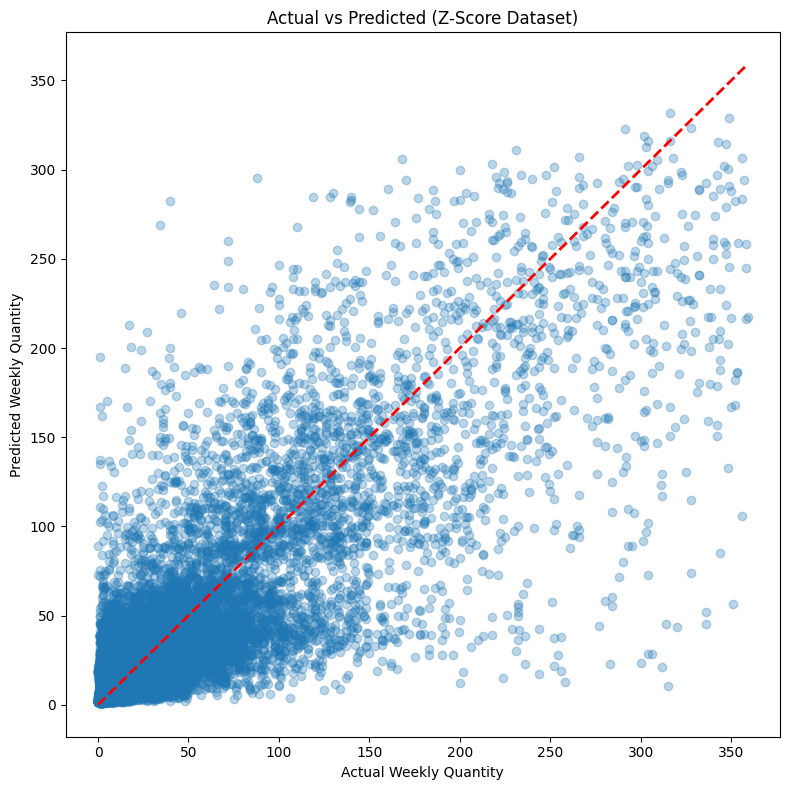

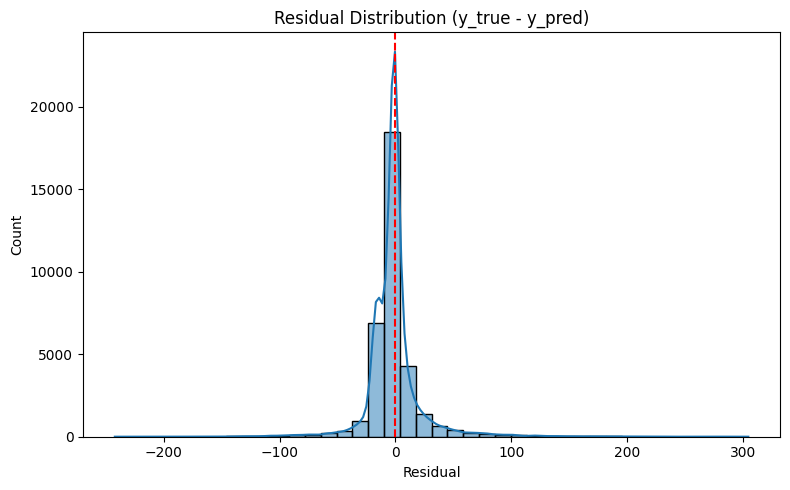

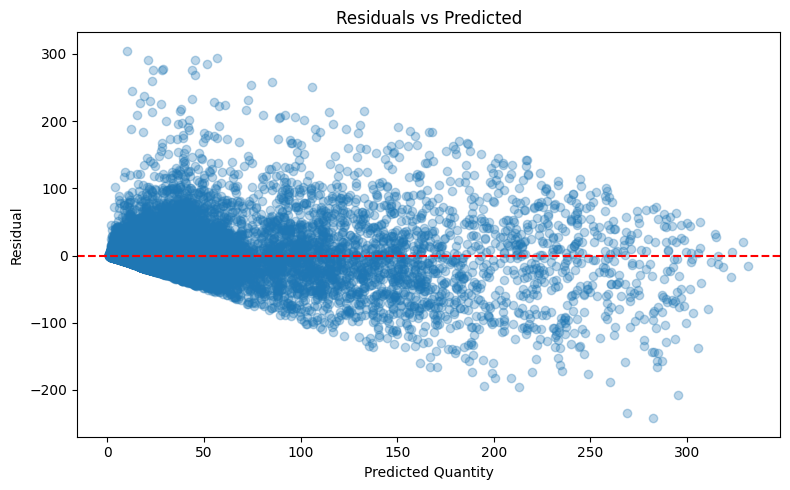

Saved figures:
- C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\figures\actual_vs_predicted_weekly_zscore.png
- C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\figures\residual_hist_weekly_zscore.png
- C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\figures\residual_vs_pred_weekly_zscore.png


In [13]:
predictions_z = test_z[['article', 'year', 'week']].copy()
predictions_z['y_true'] = y_test_z.values
predictions_z['y_pred'] = y_pred_z
predictions_z['residual'] = predictions_z['y_true'] - predictions_z['y_pred']
predictions_z['abs_error'] = predictions_z['residual'].abs()

# 1) Actual vs predicted
plt.figure(figsize=(8, 8))
plt.scatter(predictions_z['y_true'], predictions_z['y_pred'], alpha=0.3)
min_val = float(min(predictions_z['y_true'].min(), predictions_z['y_pred'].min()))
max_val = float(max(predictions_z['y_true'].max(), predictions_z['y_pred'].max()))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel('Actual Weekly Quantity')
plt.ylabel('Predicted Weekly Quantity')
plt.title('Actual vs Predicted (Z-Score Dataset)')
plt.tight_layout()
fig_actual_pred = FIG_DIR / 'actual_vs_predicted_weekly_zscore.png'
plt.savefig(fig_actual_pred, dpi=150)
plt.show()

# 2) Residual distribution
plt.figure(figsize=(8, 5))
sns.histplot(predictions_z['residual'], bins=40, kde=True)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Distribution (y_true - y_pred)')
plt.xlabel('Residual')
plt.tight_layout()
fig_resid_hist = FIG_DIR / 'residual_hist_weekly_zscore.png'
plt.savefig(fig_resid_hist, dpi=150)
plt.show()

# 3) Residuals vs predictions
plt.figure(figsize=(8, 5))
plt.scatter(predictions_z['y_pred'], predictions_z['residual'], alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Quantity')
plt.ylabel('Residual')
plt.tight_layout()
fig_resid_scatter = FIG_DIR / 'residual_vs_pred_weekly_zscore.png'
plt.savefig(fig_resid_scatter, dpi=150)
plt.show()

print('Saved figures:')
print('-', fig_actual_pred)
print('-', fig_resid_hist)
print('-', fig_resid_scatter)


## Step 7 - Error Analysis

Inspect worst predictions and error behavior by week and article.


Top 20 largest absolute errors:


,article,year,week,y_true,y_pred,residual,abs_error
34594,AWRES 0.5 L,2025,12,315.0,10.304172,304.695828,304.695828
35447,HAMOUD 25 CL 12 PS,2025,13,351.0,56.616528,294.383472,294.383472
58118,SOMAM ABOIR,2025,46,312.0,21.002758,290.997242,290.997242
55294,SOMAM NATURE,2025,42,336.0,45.344044,290.655956,290.655956
55921,SOMAM BECOUCHE,2025,43,336.0,51.740398,284.259602,284.259602
49230,SOMAM CREME DESSERT GM,2025,33,306.0,28.570221,277.429779,277.429779
34423,QNIAA 1L 8PS PROMO,2025,11,300.0,23.375633,276.624367,276.624367
51890,SOMAM TARTE POT,2025,37,320.0,43.724072,276.275928,276.275928
59473,SOMAM NATURE,2025,48,304.0,28.206692,275.793308,275.793308
51899,SOMAM NATURE,2025,37,314.0,45.487270,268.512730,268.512730


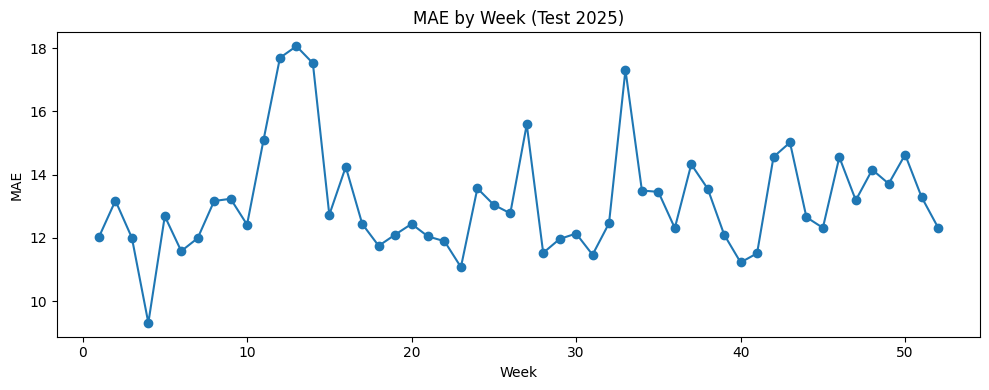

Top 15 articles by test volume with MAE:


,article,mae,n
459,DAILY 20 CL 30PS,56.858572,52
1304,OMO 330 G,49.945835,52
1397,PRIMA CHOCO 30 PS,49.691627,52
491,DOUBLE MIX,47.702533,52
1486,SACHET SUPER 1 KG,47.395310,52
844,ISIS LIQUIDE 750 CL,44.585297,52
355,CHREA 1 L,44.247632,52
864,KARANTITA READHE 20 PS,44.194960,52
19,AFRAH GAUFRETTE 24 PS,43.918678,52
246,CAFE FAMICO,43.560077,52


Saved figure: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\figures\weekly_mae_weekly_zscore.png


In [14]:
# Worst errors
top_errors = predictions_z.sort_values('abs_error', ascending=False).head(20)
print('Top 20 largest absolute errors:')
display(top_errors)

# Weekly error summary
weekly_error = predictions_z.groupby('week', as_index=False).agg(
    mae=('abs_error', 'mean'),
    rmse=('residual', lambda x: float(np.sqrt(np.mean(np.square(x))))),
    n=('residual', 'size')
)

plt.figure(figsize=(10, 4))
plt.plot(weekly_error['week'], weekly_error['mae'], marker='o')
plt.title('MAE by Week (Test 2025)')
plt.xlabel('Week')
plt.ylabel('MAE')
plt.tight_layout()
fig_weekly_mae = FIG_DIR / 'weekly_mae_weekly_zscore.png'
plt.savefig(fig_weekly_mae, dpi=150)
plt.show()

# Article-level error summary (top volume in test)
article_error = predictions_z.groupby('article', as_index=False).agg(
    mae=('abs_error', 'mean'),
    n=('abs_error', 'size')
).sort_values(['n', 'mae'], ascending=[False, False])

print('Top 15 articles by test volume with MAE:')
display(article_error.head(15))
print('Saved figure:', fig_weekly_mae)


## Step 8 - SHAP Explainability

Generate beeswarm and bar SHAP plots for the z-score model.


In [15]:
import shap

sample_n = min(2000, len(X_test_z))
X_test_sample_z = X_test_z.sample(sample_n, random_state=42) if len(X_test_z) > sample_n else X_test_z.copy()

explainer_z = shap.TreeExplainer(xgb_z)
shap_values_z = explainer_z.shap_values(X_test_sample_z)

# Beeswarm plot
shap.summary_plot(shap_values_z, X_test_sample_z, show=False)
plt.tight_layout()
fig_shap_beeswarm = FIG_DIR / 'shap_beeswarm_weekly_zscore.png'
plt.savefig(fig_shap_beeswarm, dpi=150, bbox_inches='tight')
plt.close()

# Bar plot
shap.summary_plot(shap_values_z, X_test_sample_z, plot_type='bar', show=False)
plt.tight_layout()
fig_shap_bar = FIG_DIR / 'shap_bar_weekly_zscore.png'
plt.savefig(fig_shap_bar, dpi=150, bbox_inches='tight')
plt.close()

print('Saved SHAP beeswarm:', fig_shap_beeswarm)
print('Saved SHAP bar:', fig_shap_bar)


Saved SHAP beeswarm: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\figures\shap_beeswarm_weekly_zscore.png
Saved SHAP bar: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\figures\shap_bar_weekly_zscore.png


## Step 9 - ANOVA on Error

Run one-way ANOVA to test if absolute error differs by week groups.


In [16]:
# Build week groups (Q1..Q4 of week index) for ANOVA
predictions_z['week_group'] = pd.qcut(predictions_z['week'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

anova_groups = [
    predictions_z.loc[predictions_z['week_group'] == g, 'abs_error'].values
    for g in ['Q1', 'Q2', 'Q3', 'Q4']
]

if all(len(g) > 1 for g in anova_groups):
    f_stat, p_value = f_oneway(*anova_groups)
    print(f'ANOVA F-statistic: {f_stat:.4f}')
    print(f'ANOVA p-value: {p_value:.6f}')
    if p_value < 0.05:
        print('Result: Significant difference in mean absolute error across week groups (p < 0.05).')
    else:
        print('Result: No significant difference in mean absolute error across week groups (p >= 0.05).')
else:
    print('Not enough samples in one or more groups for ANOVA.')


ANOVA F-statistic: 3.6530
ANOVA p-value: 0.011959
Result: Significant difference in mean absolute error across week groups (p < 0.05).


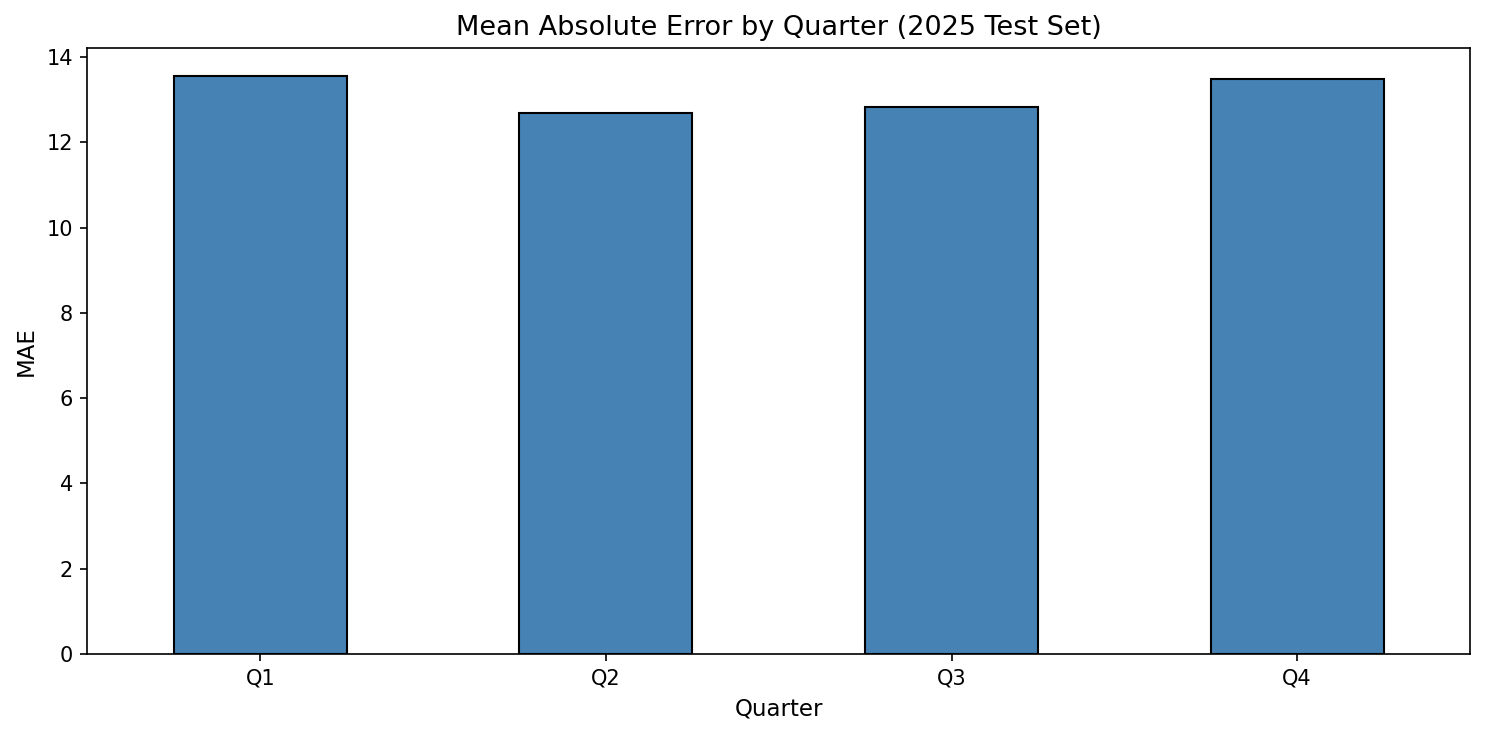

In [22]:
predictions_z['week_group'] = pd.qcut(predictions_z['week'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
predictions_z.groupby('week_group')['abs_error'].mean().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Mean Absolute Error by Quarter (2025 Test Set)', fontsize=13)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACT_ROOT / 'figures' / 'anova_mae_by_quarter.png', dpi=150)
plt.show()

## Step 10 - Save Artifacts

Save model and prediction file for the z-score pipeline.


In [17]:
model_path_z = MODEL_DIR / 'xgb_model_weekly_zscore.pkl'
pred_path_z = MODEL_DIR / 'predictions_weekly_zscore.csv'

joblib.dump({
    'model': xgb_z,
    'feature_cols': feature_cols_z,
    'target_encoding_map': article_te_map_z.to_dict(),
    'target_encoding_global_mean': float(global_target_mean_z),
    'preprocessing': 'z-score filter on quantite, threshold=3'
}, model_path_z)

predictions_z[['article', 'year', 'week', 'y_true', 'y_pred', 'residual', 'abs_error']].to_csv(pred_path_z, index=False)

print('Saved model:', model_path_z)
print('Saved predictions:', pred_path_z)


Saved model: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\models\xgb_model_weekly_zscore.pkl
Saved predictions: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\models\predictions_weekly_zscore.csv


## Step 11 - Forecast 2026 (Weekly)

Use the trained z-score model to recursively forecast weekly quantity for ISO year 2026.
Assumption: `prix_de_vente` in 2026 is held at each article's latest known value.


Weeks forecasted: 53
Total rows forecasted: 105470
Saved forecast: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\models\forecast_weekly_2026_zscore.csv


,article,year,week,y_forecast
0,/ ELIO 1L 10PS,2026,1,19.071524
1,/ ELIO 1L 10PS,2026,2,18.909307
2,/ ELIO 1L 10PS,2026,3,18.426369
3,/ ELIO 1L 10PS,2026,4,19.007982
4,/ ELIO 1L 10PS,2026,5,19.473917
5,/ ELIO 1L 10PS,2026,6,19.473917
6,/ ELIO 1L 10PS,2026,7,19.733047
7,/ ELIO 1L 10PS,2026,8,19.733047
8,/ ELIO 1L 10PS,2026,9,19.766264
9,/ ELIO 1L 10PS,2026,10,19.710747


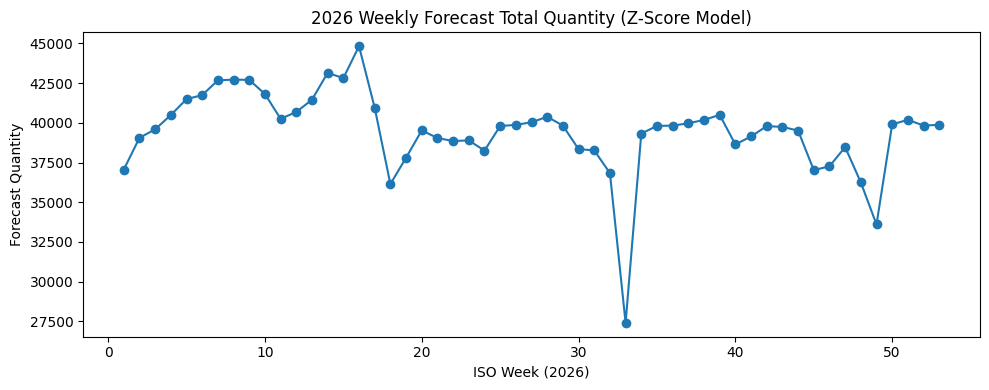

Saved forecast figure: C:\Users\H-Info\OneDrive\Desktop\graduation_project\churn_predection_2425\Notebooks\artifacts\figures\forecast_total_2026_weekly_zscore.png


In [18]:
# Recursive weekly forecast for 2026
last_week_2026 = int(pd.Timestamp('2026-12-28').isocalendar().week)
weeks_2026 = list(range(1, last_week_2026 + 1))

# Latest known selling price per article
price_map = (
    weekly_z.sort_values(['year', 'week'])
    .groupby('article')['prix_de_vente']
    .last()
    .to_dict()
)

def build_history(series):
    vals = [float(v) for v in series.tolist() if pd.notna(v)]
    if not vals:
        vals = [float(global_target_mean_z)] * 4
    while len(vals) < 4:
        vals.insert(0, vals[0])
    return vals

forecast_rows = []
articles = sorted(weekly_z['article'].astype(str).unique())

for article in articles:
    hist_series = weekly_z.loc[weekly_z['article'].astype(str) == article, 'quantite']
    hist = build_history(hist_series)

    article_te_val = article_te_map_z.get(article, global_target_mean_z)
    price_val = float(price_map.get(article, weekly_z['prix_de_vente'].median()))

    for wk in weeks_2026:
        lag_1 = hist[-1]
        lag_2 = hist[-2]
        lag_4 = hist[-4]
        rolling_mean_4 = float(np.mean(hist[-4:]))

        row = pd.DataFrame([{
            'article_te': float(article_te_val),
            'year': 2026,
            'week': int(wk),
            'prix_de_vente': price_val,
            'lag_1': float(lag_1),
            'lag_2': float(lag_2),
            'lag_4': float(lag_4),
            'rolling_mean_4': float(rolling_mean_4),
        }])

        pred = float(np.clip(xgb_z.predict(row[feature_cols_z])[0], 0, None))
        hist.append(pred)

        forecast_rows.append({
            'article': article,
            'year': 2026,
            'week': int(wk),
            'y_forecast': pred
        })

forecast_2026 = pd.DataFrame(forecast_rows)
forecast_2026_path = MODEL_DIR / 'forecast_weekly_2026_zscore.csv'
forecast_2026.to_csv(forecast_2026_path, index=False)

print('Weeks forecasted:', len(weeks_2026))
print('Total rows forecasted:', len(forecast_2026))
print('Saved forecast:', forecast_2026_path)
display(forecast_2026.head(10))

# Graph: total forecast by week
weekly_total_2026 = forecast_2026.groupby('week', as_index=False)['y_forecast'].sum()
plt.figure(figsize=(10, 4))
plt.plot(weekly_total_2026['week'], weekly_total_2026['y_forecast'], marker='o')
plt.title('2026 Weekly Forecast Total Quantity (Z-Score Model)')
plt.xlabel('ISO Week (2026)')
plt.ylabel('Forecast Quantity')
plt.tight_layout()
fig_forecast_2026 = FIG_DIR / 'forecast_total_2026_weekly_zscore.png'
plt.savefig(fig_forecast_2026, dpi=150)
plt.show()

print('Saved forecast figure:', fig_forecast_2026)


In [19]:
from sklearn.metrics import mean_absolute_error, median_absolute_error

mae = mean_absolute_error(y_test_z, y_pred_z)
medae = median_absolute_error(y_test_z, y_pred_z)

print(f"MAE   : {mae:.4f}")
print(f"MedAE : {medae:.4f}")
print(f"MAE/MedAE ratio: {mae/medae:.2f}")

MAE   : 13.1356
MedAE : 6.0832
MAE/MedAE ratio: 2.16


In [20]:
# Model metrics (already_HAVE)
mae_model = mean_absolute_error(y_test_z, y_pred_z)
medae_model = median_absolute_error(y_test_z, y_pred_z)

# Baseline: predict with lag_1
y_pred_base = X_test_z['lag_1'].values
mae_base = mean_absolute_error(y_test_z, y_pred_base)
medae_base = median_absolute_error(y_test_z, y_pred_base)

cmp = pd.DataFrame({
    'Model': ['XGBoost_Zscore', 'Baseline_lag1'],
    'MAE': [mae_model, mae_base],
    'MedAE': [medae_model, medae_base]
})
print(cmp)

print(f"MAE improvement vs baseline: {(mae_base - mae_model)/mae_base*100:.2f}%")
print(f"MedAE improvement vs baseline: {(medae_base - medae_model)/medae_base*100:.2f}%")

            Model        MAE    MedAE
0  XGBoost_Zscore  13.135608  6.08319
1   Baseline_lag1  14.803374  4.50000
MAE improvement vs baseline: 11.27%
MedAE improvement vs baseline: -35.18%


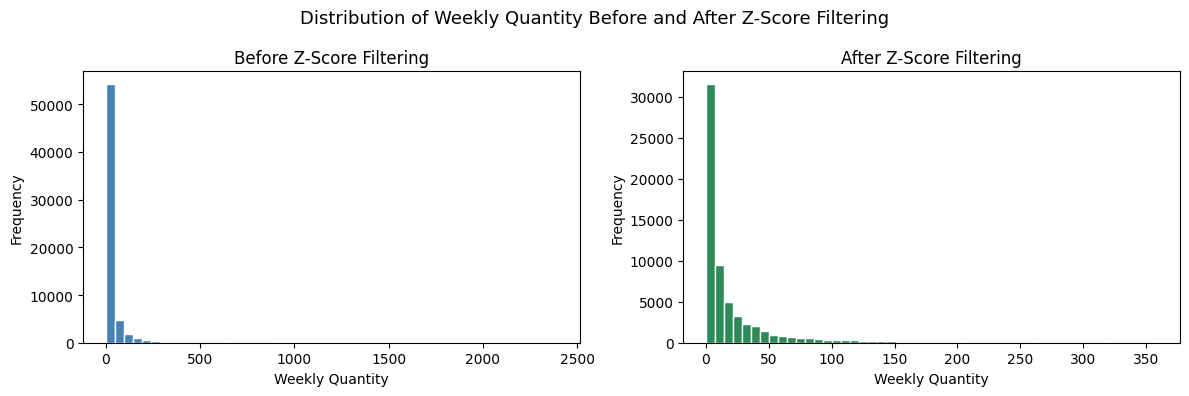

Rows before: 64253
Rows after: 63021
Rows removed: 1232


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before filtering
weekly['quantite'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Before Z-Score Filtering')
axes[0].set_xlabel('Weekly Quantity')
axes[0].set_ylabel('Frequency')

# After filtering
weekly_z['quantite'].plot(kind='hist', bins=50, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('After Z-Score Filtering')
axes[1].set_xlabel('Weekly Quantity')
axes[1].set_ylabel('Frequency')

plt.suptitle('Distribution of Weekly Quantity Before and After Z-Score Filtering', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_18_zscore_filtering.png', dpi=150)
plt.show()

print('Rows before:', len(weekly))
print('Rows after:', len(weekly_z))
print('Rows removed:', len(weekly) - len(weekly_z))